# Treinamento e Avaliação com XGBoost
Este notebook treina um modelo XGBoost para prever `preco_medio_ton_usd` e avalia o desempenho usando MSE, RMSE e R².

Tipo de carne: bovino
Target: preco_medio_ton_usd
Amostras de treino: 32
Amostras de teste: 8
MSE: 0.3840
RMSE: 0.6196
R²: -10.3730


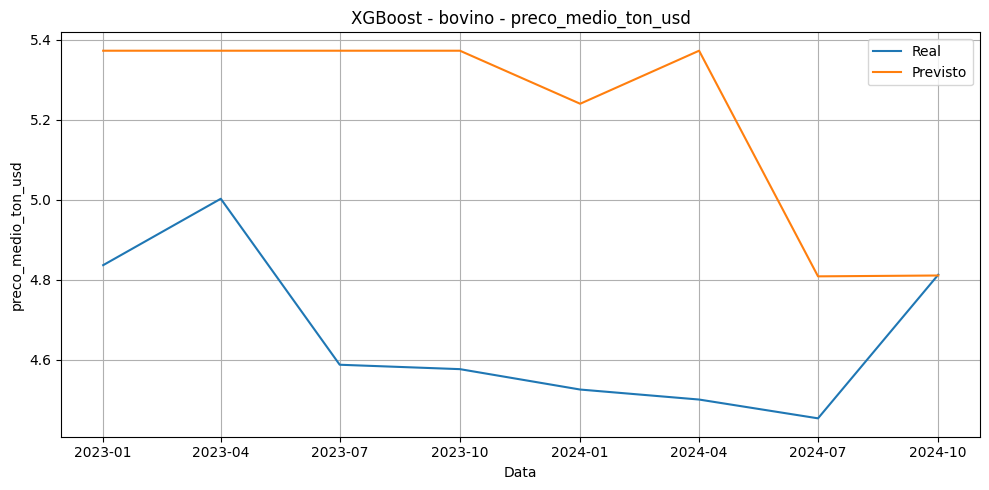

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Carregar dados
df = pd.read_csv("/content/carne-brasileira-exportada.csv")
df["date"] = pd.to_datetime(
    df["ano"].astype(str)
    + "-"
    + ((df["trimestre"] - 1) * 3 + 1).astype(str).str.zfill(2)
    + "-01"
)
df = df.sort_values(["tipo_carne", "date"]).reset_index(drop=True)

# Configurar target e tipo de carne
target_column = "preco_medio_ton_usd"  # altere para "exportacao_usd" se quiser outro alvo
meat_type = "bovino"  # altere para "suino" ou "frango"

df_filtered = df[df["tipo_carne"] == meat_type].copy()
df_filtered = df_filtered.sort_values("date").reset_index(drop=True)

df_filtered["time_index"] = np.arange(len(df_filtered))
df_filtered["quarter_sin"] = np.sin(2 * np.pi * (df_filtered["trimestre"] - 1) / 4)
df_filtered["quarter_cos"] = np.cos(2 * np.pi * (df_filtered["trimestre"] - 1) / 4)

df_filtered[f"{target_column}_lag1"] = df_filtered[target_column].shift(1)
df_filtered[f"{target_column}_lag2"] = df_filtered[target_column].shift(2)
df_filtered[f"{target_column}_lag4"] = df_filtered[target_column].shift(4)

df_filtered["rolling_mean_4"] = df_filtered[target_column].shift(1).rolling(window=4, min_periods=1).mean()
df_filtered["pct_change_4q"] = df_filtered[target_column].pct_change(periods=4)

feature_columns = [
    "time_index",
    "quarter_sin",
    "quarter_cos",
    "producao_cabecas_anual_mi",
    "abate_cabecas",
    "peso_carcaca_ton",
    "media_cambio_usdbrl",
    "custo_milho_rs",
    "custo_soja_rs",
    f"{target_column}_lag1",
    f"{target_column}_lag2",
    f"{target_column}_lag4",
    "rolling_mean_4",
    "pct_change_4q",
]

df_model = df_filtered.dropna(subset=feature_columns + [target_column]).reset_index(drop=True)

train_size = int(len(df_model) * 0.8)
train = df_model.iloc[:train_size]
test = df_model.iloc[train_size:]

X_train = train[feature_columns]
y_train = train[target_column]
X_test = test[feature_columns]
y_test = test[target_column]

model = XGBRegressor(n_estimators=200, random_state=42, objective="reg:squarederror")
model.fit(X_train, y_train)

predictions = model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print(f"Tipo de carne: {meat_type}")
print(f"Target: {target_column}")
print(f"Amostras de treino: {len(X_train)}")
print(f"Amostras de teste: {len(X_test)}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(test["date"].reset_index(drop=True), y_test.values, label="Real")
plt.plot(test["date"].reset_index(drop=True), predictions, label="Previsto")
plt.title(f"XGBoost - {meat_type} - {target_column}")
plt.xlabel("Data")
plt.ylabel(target_column)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()